# End-to-End Churn Analysis and Prediction

Customer churn is one of the most critical metrics in subscription-based businesses.
Acquiring a new customer costs significantly more than retaining an existing one,
making early identification of at-risk customers a high-value business problem.

This notebook presents a full analytical pipeline applied to a telecom dataset of 7,000+ customers,
combining **unsupervised** and **supervised** machine learning techniques to uncover
behavioral patterns and predict churn at the individual customer level.


##### **Business Output**
A scored dataset, one row per customer, flagging churn risk and probability.

##### **Tools & Methodology**

Machine Learning Implementation:
- Sentiment analysis: Hugging Face transformer model (cardiffnlp/twitter-roberta-base-sentiment)
- Topic classification: keyword-based method
- Feature engineering: One-hot encoding, ordinal encoding, standard scaling
- Dimensionality reduction: PCA with proper train/test split
- Clustering: K-Means with elbow method optimization
- Predictive modeling: Random Forest classifier with stratified sampling
- Evaluation: Classification report, confusion matrix, feature importance analysis

LLM-Assisted Components:
- Sentiment analysis
- Topic classification
- Cluster labeling: Claude API to generate business-friendly segment names from numerical profiles

[Dataset — Kaggle: Telco Customer Churn with Realistic Feedback](https://www.kaggle.com/datasets/beatafaron/telco-customer-churn-realistic-customer-feedback?select=telco_churn_with_all_feedback.csv)

## Setup & Initial Data Look <a id="setup"></a>

Before any analysis, we load the tools we need and take a first look at the data.
This section answers three basic questions: What columns do we have? What do the values look like?
Are there any missing or unexpected values we need to deal with later?


In [ ]:
# Core libraries for data manipulation, numerical computation, and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the Telco customer dataset into a DataFrame for analysis
df = pd.read_csv(r'/content/drive/MyDrive/Python - Personal Projects/telco_churn_with_all_feedback.csv')


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Check dataset dimension
rows, cols = df.shape
print(f"The dataset contains {rows} rows and {cols} columns.")

The dataset contains 7043 rows and 23 columns.


In [ ]:
# Summarize the dataset — column names, data types, and missing value counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# Set max column width to see text reviews in full
pd.set_option('display.max_colwidth', None)

# Check random samples
df.sample(5, random_state=42)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,PromptInput,CustomerFeedback
185,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,24.80,24.8,Yes,Write a realistic customer feedback based on this profile:\nChurn: Yes\nTenure: 1 months\nContract type: Month-to-month\nMonthly Charges: $24.8\nInternet Service: DSL\nPayment Method: Electronic check,"I recently switched to this DSL internet service provider and unfortunately, I experienced constant interruptions in my service. The speed was inconsistent and I had trouble staying connected while working from home. Additionally, I found the monthly charges to be quite high for the level of service I was receiving. I decided to cancel my subscription after only one month due to these issues. I hope the provider can improve their service quality in the future."
2715,1173-XZPYF,Female,0,No,No,11,Yes,Yes,Fiber optic,No,...,Yes,No,Month-to-month,Yes,Electronic check,89.20,990.3,No,Write a realistic customer feedback based on this profile:\nChurn: No\nTenure: 11 months\nContract type: Month-to-month\nMonthly Charges: $89.2\nInternet Service: Fiber optic\nPayment Method: Electronic check,"I have been a customer with this company for 11 months now and I am very satisfied with their fiber optic internet service. The monthly charges of $89.2 are reasonable for the quality of service I am receiving. I appreciate the convenience of being able to pay through electronic check. Overall, I have had a positive experience with this company and have no intentions of churning."
3825,6260-ONULR,Male,0,No,No,1,Yes,No,DSL,No,...,Yes,Yes,Month-to-month,Yes,Mailed check,62.80,62.8,No,Write a realistic customer feedback based on this profile:\nChurn: No\nTenure: 1 months\nContract type: Month-to-month\nMonthly Charges: $62.8\nInternet Service: DSL\nPayment Method: Mailed check,"I have been a customer with this DSL internet service provider for 1 month now and I am very satisfied with the service. The monthly charges are reasonable at $62.8 and the internet connection has been reliable. I appreciate the option to pay via mailed check as it is convenient for me. Overall, I have had a positive experience with this provider and I have no plans to churn in the near future."
1807,8464-EETCQ,Male,0,No,No,57,Yes,No,No,No internet service,...,No internet service,No internet service,Two year,No,Credit card (automatic),18.80,1094.35,No,Write a realistic customer feedback based on this profile:\nChurn: No\nTenure: 57 months\nContract type: Two year\nMonthly Charges: $18.8\nInternet Service: No\nPayment Method: Credit card (automatic),"I have been a loyal customer for over 4 and a half years and have been very satisfied with the service provided by this company. The automatic credit card payment option has made it convenient for me to pay my monthly charges without any hassle. Although I do not have internet service with this company, the low monthly charges of $18.8 for my other services have been very reasonable. I have had no issues with my contract type and have not experienced any churn. Overall, I am happy with the service and would recommend it to others."
132,8587-XYZSF,Male,0,No,No,67,Yes,No,DSL,No,...,No,No,Two year,No,Bank transfer (automatic),50.55,3260.1,No,Write a realistic customer feedback based on this profile:\nChurn: No\nTenure: 67 months\nContract type: Two year\nMonthly Charges: $50.55\nInternet Service: DSL\nPayment Method: Bank transfer (automatic),"I have been a customer with this DSL internet service provider for over five years now and I have been very satisfied with their service. The automatic bank transfer payment method is convenient and hassle-free. The monthly charges of $50.55 are reasonable for the quality of service provided. I have not experienced any issues with 

In [ ]:
# Generate descriptive statistics for all numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.0000,0.00000,0.0000,0.00000,1.0000
tenure,7043.0,32.371149,24.559481,0.0000,9.00000,29.0000,55.00000,72.0000
MonthlyCharges,7043.0,64.761692,30.090047,18.2500,35.50000,70.3500,89.85000,118.7500
TotalCharges,7043.0,2279.734304,2266.794470,0.0000,398.55000,1394.5500,3786.60000,8684.8000
Churn,7043.0,0.265370,0.441561,0.0000,0.00000,0.0000,1.00000,1.0000
sentiment_score_nlp,7043.0,0.906439,0.145530,0.3593,0.92500,0.9714,0.98175,0.9913
ChurnProbability,7043.0,0.362725,0.298738,0.0020,0.07835,0.2906,0.63755,0.9502
ChurnPrediction,7043.0,0.274599,0.446344,0.0000,0.00000,0.0000,1.00000,1.0000


##### Key Takeaways

- The dataset has **7,043 customers** and **23 columns** — no missing values across any column.
- `TotalCharges` is stored as a string instead of a number, which will block any numerical analysis. This will be fixed in the next section.
- `PromptInput` is an AI-generated prompt column with no analytical value and will be dropped.
- All other columns are in the expected format and ready for analysis.

## Data Cleaning <a id="cleaning"></a>

This section addresses the two issues identified during the initial data look:
an incorrectly typed column and an irrelevant column that adds noise to the analysis.
No rows are dropped unless conversion fails.

In [ ]:
# Strip whitespace and convert TotalCharges to numeric
df['TotalCharges'] = df['TotalCharges'].str.strip() #remove white spaces, tabs, or new lines
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce') # coerce = empty or non-numeric = NaN

# Impute missing TotalCharges using tenure x MonthlyCharges instead of dropping
df['TotalCharges'] = df['TotalCharges'].fillna(df['tenure'] * df['MonthlyCharges'])

# Drop PromptInput column
df.drop(columns=['PromptInput'], inplace=True)

# Confirm all rows are retained and no nulls remain
print(f"Dataset shape: {df.shape}")
print(f"Nulls in TotalCharges: {df['TotalCharges'].isnull().sum()}")


Dataset shape: (7043, 22)
Nulls in TotalCharges: 0


##### Key Takeaways

- `TotalCharges` had 11 rows with empty or whitespace values that could not be converted to a number.
- Rather than dropping these rows, missing values were imputed using `tenure x MonthlyCharges` — the logical business relationship behind the column. This ensures no customer is excluded from the final churn prediction output.
- `PromptInput` has been dropped, leaving the dataset at 22 columns.
- The cleaned dataset retains all 7,043 customers and is ready for exploratory analysis.


## Exploratory Data Analysis <a id="eda"></a>

This section explores the distribution of key variables and their relationship to churn.
The goal is to surface patterns in the data that inform our modeling decisions and
generate early business insights.


Churn distribution. - establish baseline churn %

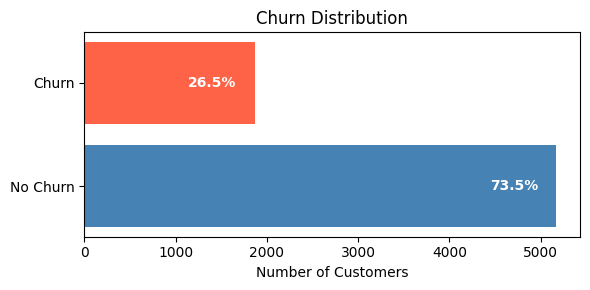

In [ ]:
# Visualize the overall split between customers who churned and those who stayed
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True).mul(100).round(1)

fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.barh(['No Churn', 'Churn'], churn_counts.values, color=['steelblue', 'tomato'])

# Add percentage labels inside each bar
for bar, pct in zip(bars, churn_pct.values):
    ax.text(bar.get_width() - 200, bar.get_y() + bar.get_height() / 2,
            f'{pct}%', va='center', ha='right', fontweight='bold', color='white')

ax.set_title('Churn Distribution')
ax.set_xlabel('Number of Customers')
plt.tight_layout()
plt.show()


**Churn Distribution:** 26.5% of customers churned (1 in 4).

Categorical feature distribution

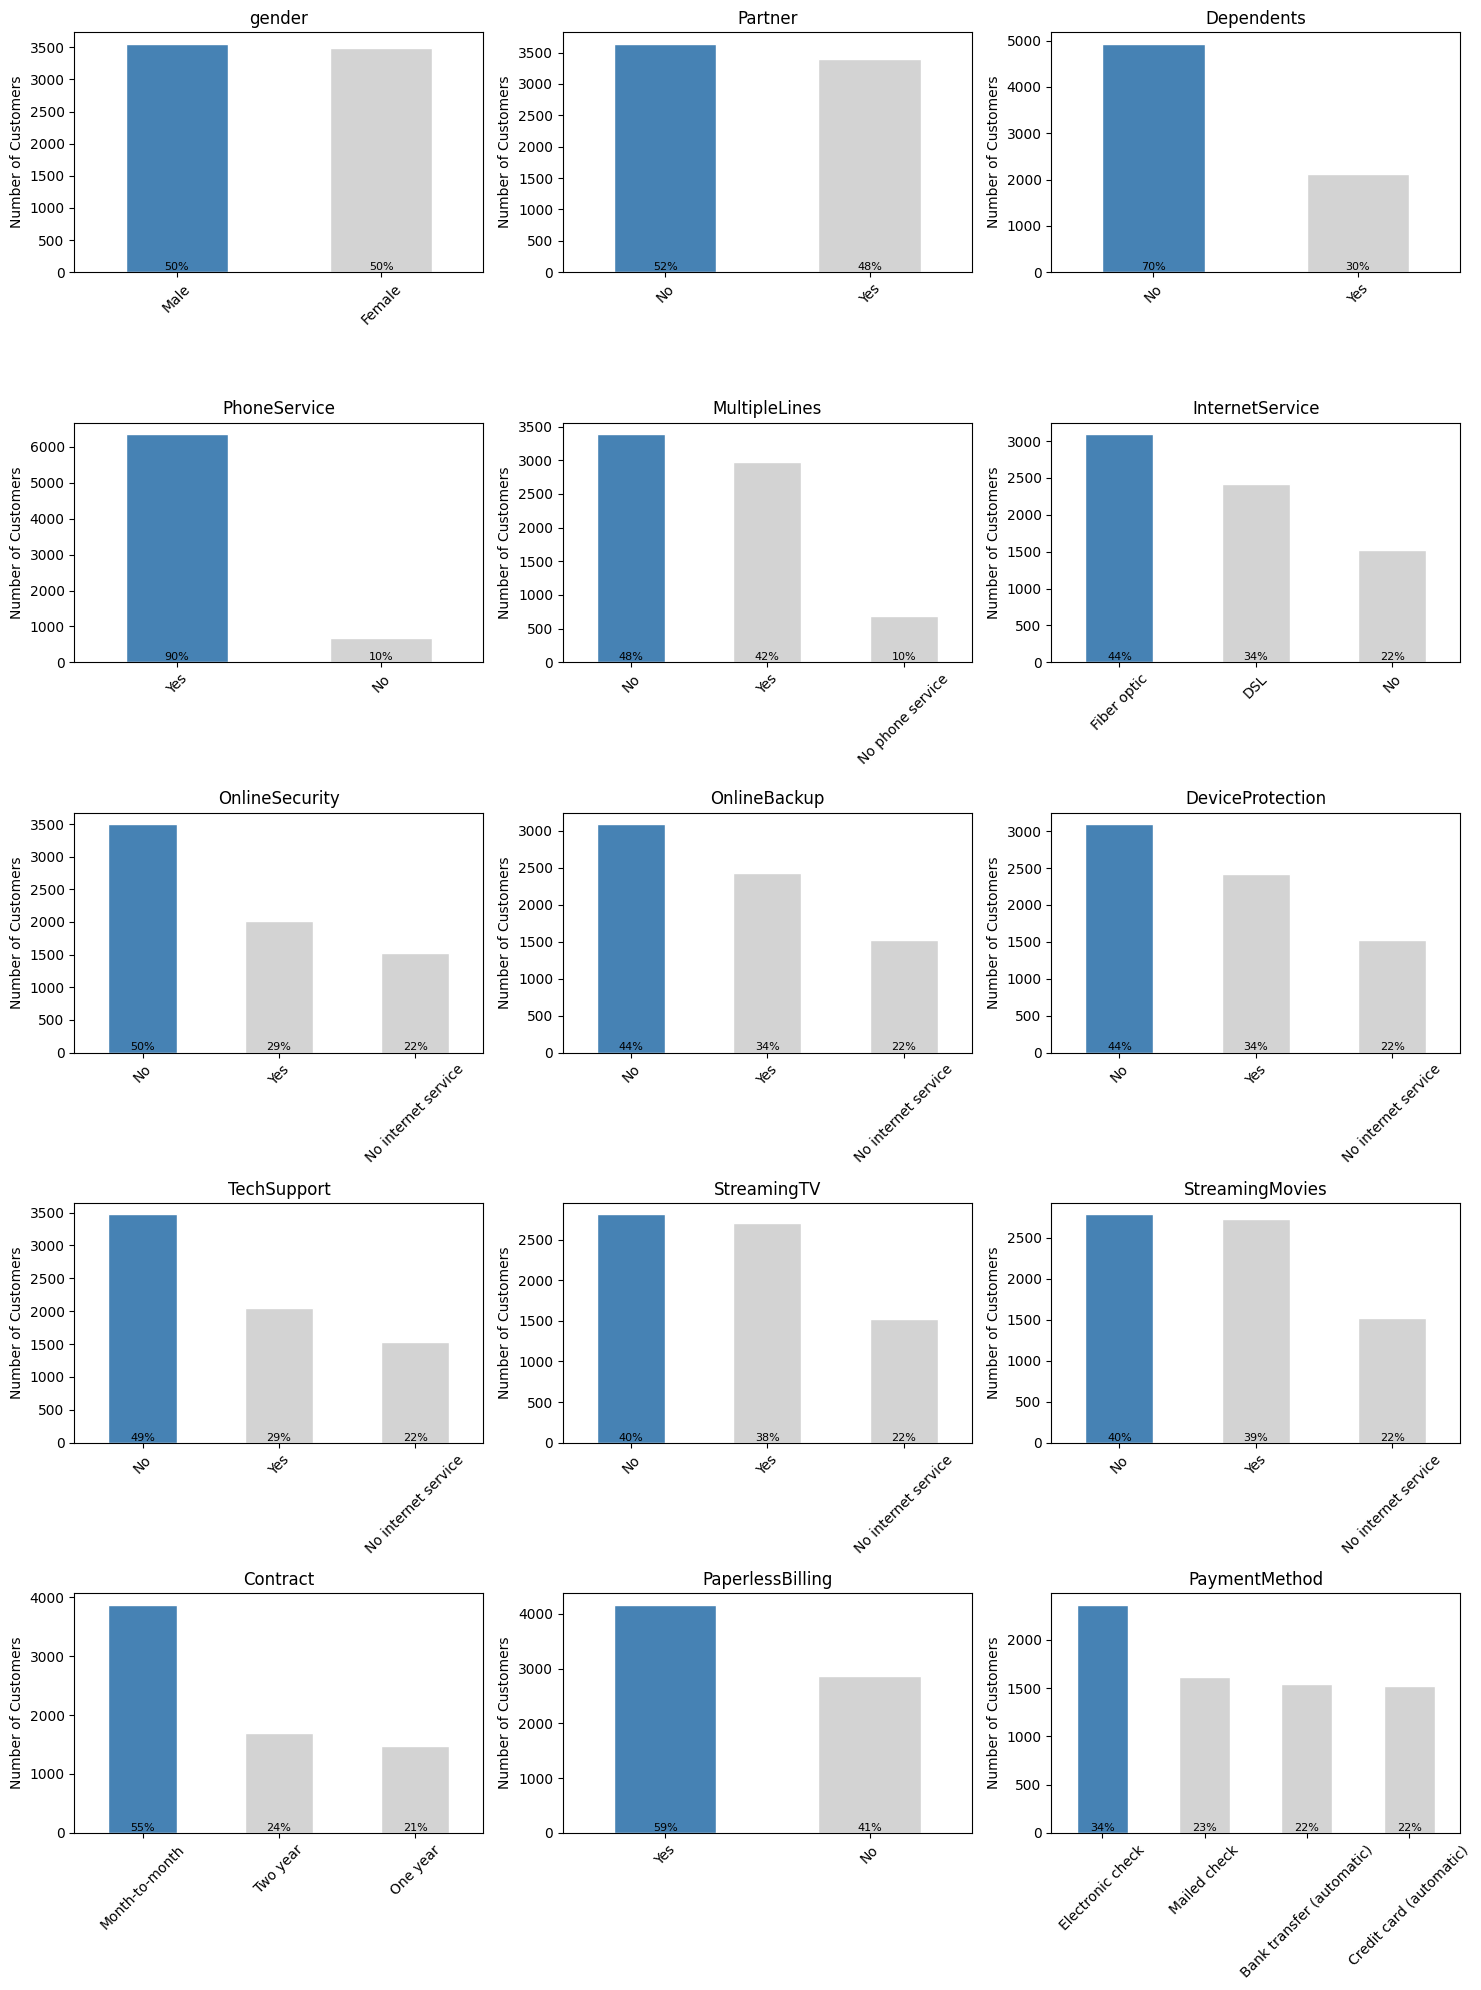

In [ ]:
# Visualize how customers are distributed across each categorical feature
cat_columns = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
               'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
               'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
               'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(cat_columns):
    counts = df[col].value_counts()
    pcts = (counts / len(df) * 100).round(0)

    # Color only the highest bar, gray out the rest
    colors = ['steelblue' if v == counts.max() else 'lightgray' for v in counts.values]

    counts.plot(kind='bar', ax=axes[i], color=colors, edgecolor='white')

    # Add % label at the bottom of each bar
    for bar, pct in zip(axes[i].patches, pcts.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2, 1,
                     f'{int(pct)}%', ha='center', va='bottom', fontsize=8)

    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Number of Customers')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


**Customer Profile Snapshot:**
- Gender is nearly evenly split: unlikely to be a strong churn predictor.
- Most customers (~70%) have no dependents and no partner, suggesting a largely single or independent customer base
- The majority are on **month-to-month contracts**
- **Fiber optic** is the most subscribed internet service, followed by DSL
- Most customers do not subscribe to add-on services (OnlineSecurity, TechSupport, DeviceProtection)
- **Electronic check** is the most common payment method, which we will later see is associated with higher churn


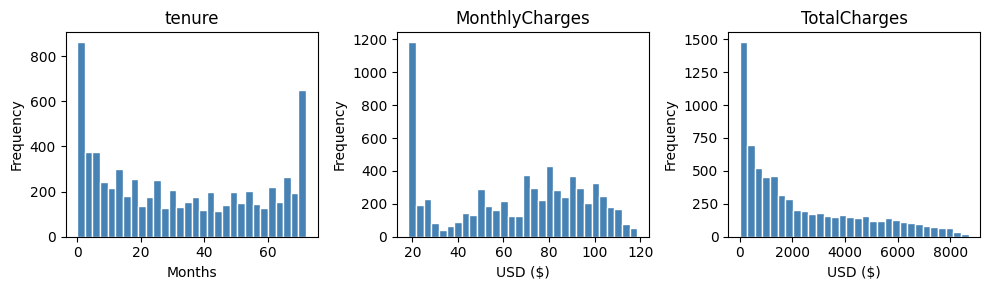

In [ ]:
# Plot distributions of numerical columns to check for skew and outliers
num_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']
x_labels = ['Months', 'USD ($)', 'USD ($)']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 3))

for i, col in enumerate(num_columns):
    df[col].plot(kind='hist', ax=axes[i], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel(x_labels[i])
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


**Numerical Feature Distributions:**

- **Tenure** is bimodal: heavy spikes at month 1 and month 70+, suggesting customers either leave early or stay long-term with little in between.
- **MonthlyCharges** clusters around 20usd (base plan) then spreads up to 120usd, indicating a wide range of plan tiers.
- **TotalCharges** is right-skewed with a large spike near $0. This is expected: customers who have only been with the company for a short time have not yet accumulated much in total billing. The column will be scaled before modeling to prevent large values from skewing the results.


Let's explore the relationship between `tenure` and `Contract` type to understand the bimodal distribution better. We'll visualize `tenure` distribution for each contract category.

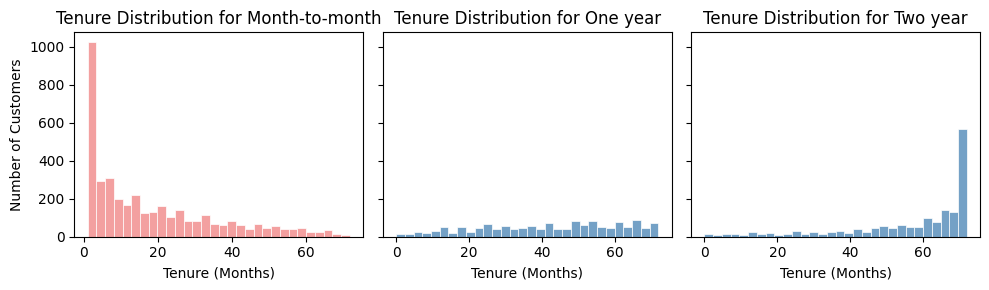

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharey=True)

contract_types = df['Contract'].unique()

for i, contract_type in enumerate(contract_types):
    subset = df[df['Contract'] == contract_type]
    sns.histplot(subset['tenure'], bins=30, ax=axes[i], color='lightcoral' if 'Month-to-month' in contract_type else 'steelblue', edgecolor='white')
    axes[i].set_title(f'Tenure Distribution for {contract_type}')
    axes[i].set_xlabel('Tenure (Months)')
    axes[i].set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()

*   **Month-to-month** contracts contribute heavily to the early churn (spike at 1-2 months).
*   **One-year** contracts show a peak around 12 months, and then a gradual decline.
*   **Two-year** contracts lead to a strong concentration of customers at much longer tenures (around 24 months and beyond), with many staying even after their contract period ends.


## Data Preprocessing <a id="preprocessing"></a>

Before modeling, all features need to be in a numerical format that machine learning algorithms
can work with. This section encodes categorical columns, scales numerical columns,
and prepares the text column for NLP analysis.



Encode categorical columns

In [ ]:
# Convert Churn from Yes/No text to 1/0 for numerical analysis and modeling
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


In [ ]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
import pandas as pd

# Define each column group by the encoding it needs
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

nominal_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                'PaymentMethod']

ordinal_cols = ['Contract']
ordinal_order = [['Month-to-month', 'One year', 'Two year']]

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Build the transformer — each group gets its own encoding strategy
preprocessor = ColumnTransformer(transformers=[
    ('binary', OneHotEncoder(drop='if_binary', sparse_output=False), binary_cols),
    ('nominal', OneHotEncoder(drop='first', sparse_output=False), nominal_cols),
    ('ordinal', OrdinalEncoder(categories=ordinal_order), ordinal_cols),
    ('numerical', StandardScaler(), num_cols)
], remainder='passthrough') # no changes for columns not mentioned

# Apply the transformation — exclude customerID, Churn, and CustomerFeedback
cols_to_transform = binary_cols + nominal_cols + ordinal_cols + num_cols
df_model = df[cols_to_transform + ['SeniorCitizen', 'Churn']]

df_transformed = preprocessor.fit_transform(df_model)

# Rebuild as a readable DataFrame with proper column names
ohe_binary_names = preprocessor.named_transformers_['binary'].get_feature_names_out(binary_cols).tolist()
ohe_nominal_names = preprocessor.named_transformers_['nominal'].get_feature_names_out(nominal_cols).tolist()

feature_names = ohe_binary_names + ohe_nominal_names + ordinal_cols + num_cols + ['SeniorCitizen', 'Churn']
df_encoded = pd.DataFrame(df_transformed, columns=feature_names)

print(f"Encoded dataset shape: {df_encoded.shape}")
print(df_encoded.head())


Encoded dataset shape: (7043, 30)
   gender_Male  Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0          0.0          1.0             0.0               0.0   
1          1.0          0.0             0.0               1.0   
2          1.0          0.0             0.0               1.0   
3          1.0          0.0             0.0               0.0   
4          0.0          0.0             0.0               1.0   

   PaperlessBilling_Yes  MultipleLines_No phone service  MultipleLines_Yes  \
0                   1.0                             1.0                0.0   
1                   0.0                             0.0                0.0   
2                   1.0                             0.0                0.0   
3                   0.0                             1.0                0.0   
4                   1.0                             0.0                0.0   

   InternetService_Fiber optic  InternetService_No  \
0                          0.0                 0.0  

##### Key Takeaways

- Binary columns (gender, Partner, Dependents, PhoneService, PaperlessBilling) were encoded as single 0/1 columns using OneHotEncoder, no false ordering introduced.
- Multi-category nominal columns (InternetService, PaymentMethod, etc.) were OneHot encoded with the first category dropped to avoid multicollinearity.
- Contract was treated as ordinal (Month-to-month < One year < Two year) since the order carries meaningful business logic, longer contracts represent stronger customer commitment.
- Numerical columns (tenure, MonthlyCharges, TotalCharges) were standardized to a mean of 0 and standard deviation of 1 so no single column dominates during modeling.
- CustomerFeedback was preserved separately for NLP analysis in the next section.
- The final encoded dataset contains 7,043 customers across 30 features, ready for unsupervised and supervised learning.


## Unsupervised Learning <a id="unsupervised"></a>

This section extracts deeper signals from the data that go beyond the structured columns.
We analyze customer feedback text using two different sentiment models, identify recurring
complaint and satisfaction themes, then use dimensionality reduction and clustering to
surface distinct customer segments.


##### Sentiment Analysis <a id="sentiment"></a>

Customer feedback is analyzed for sentiment using two independent approaches:

**Transformer Model (cardiffnlp)**: a specialized NLP model trained on social media text,
scoring each feedback as Positive, Neutral, or Negative with a confidence score.

**LLM Analysis (Claude API)**: the same feedback is passed to Claude, which returns
both a sentiment label and a topic classification in a single call.

**Comparison**: results from both models are placed side by side to evaluate agreement,
surface disagreements, and assess which approach captures nuance more effectively.


In [ ]:
!pip install transformers


In [ ]:
from transformers import pipeline

# Load the cardiffnlp sentiment model trained on Twitter/social media text
sentiment_model = pipeline(
    model='cardiffnlp/twitter-roberta-base-sentiment',
    return_all_scores=True
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [ ]:
# Apply the sentiment model to the CustomerFeedback column
results = sentiment_model(df['CustomerFeedback'].tolist())

In [ ]:
# The model returns coded labels — map them to readable sentiment names
label_map = {'LABEL_0': 'Negative', 'LABEL_1': 'Neutral', 'LABEL_2': 'Positive'}

# Each result is already the top prediction — extract label and score directly
sentiments = []
for result in results:
    sentiments.append({
        'sentiment_label_nlp': label_map[result['label']],   # e.g. 'Negative'
        'sentiment_score_nlp': round(result['score'], 4)      # e.g. 0.9231 confidence
    })

# Convert results to a DataFrame and align row numbers with the main dataset
sentiment_df = pd.DataFrame(sentiments)
df = df.reset_index(drop=True)

# Add sentiment label and confidence score as new columns in the main dataset
df['sentiment_label_nlp'] = sentiment_df['sentiment_label_nlp']
df['sentiment_score_nlp'] = sentiment_df['sentiment_score_nlp']

# Preview the first 10 rows to verify results
print(df[['CustomerFeedback', 'sentiment_label_nlp', 'sentiment_score_nlp']].head(10))

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           CustomerFeedback  \
0                                                                                         I have been using the DSL internet service from this provider for the past month and so far, I am satisfied with the service. The connection has been reliable and the speed is sufficient for my needs. The monthly charges are reasonable at $29.85 and I appreciate the convenience of paying through electronic check. Overall, I have had a positive experience and would recommend this provider to others.   
1         

In [ ]:
# Check the structure of the first result
print(type(results[0]))
print(results[0])


<class 'dict'>
{'label': 'LABEL_2', 'score': 0.9831076860427856}


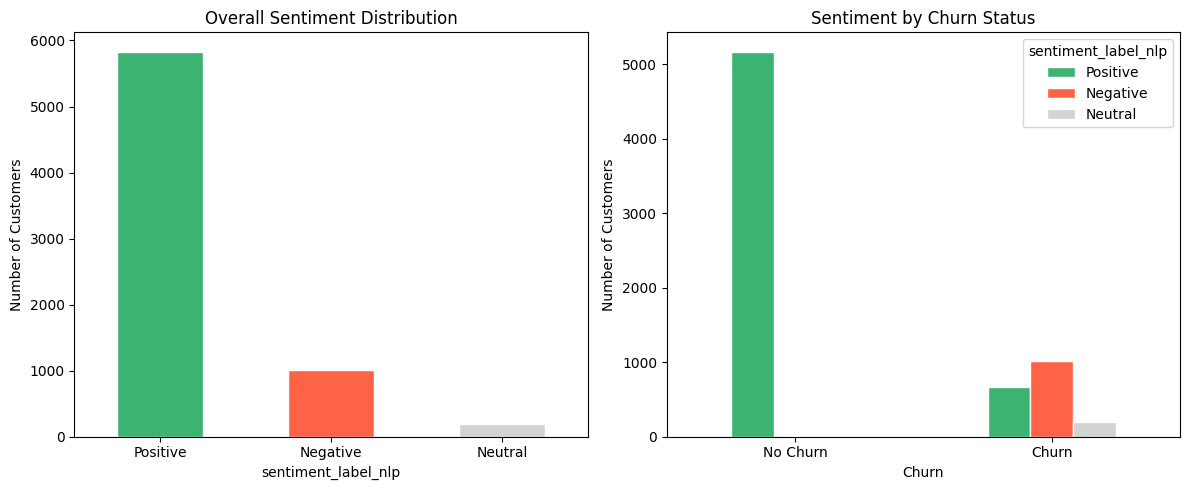

In [ ]:
# Compare sentiment distribution between churned and retained customers
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Standardized color map for sentiment labels
sentiment_colors = {'Positive': 'mediumseagreen', 'Neutral': 'lightgray', 'Negative': 'tomato'}

# Overall sentiment distribution
sentiment_counts = df['sentiment_label_nlp'].value_counts()
colors = [sentiment_colors[label] for label in sentiment_counts.index]
sentiment_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Overall Sentiment Distribution')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=0)

# Sentiment split by churn — sorted from highest to lowest total count
churn_sentiment = df.groupby(['Churn', 'sentiment_label_nlp']).size().unstack()
churn_sentiment = churn_sentiment[churn_sentiment.sum().sort_values(ascending=False).index]
bar_colors = [sentiment_colors[col] for col in churn_sentiment.columns]
churn_sentiment.plot(kind='bar', ax=axes[1], color=bar_colors, edgecolor='white')
axes[1].set_title('Sentiment by Churn Status')
axes[1].set_ylabel('Number of Customers')
axes[1].set_xticklabels(['No Churn', 'Churn'], rotation=0)

plt.tight_layout()
plt.show()


In [ ]:
# Display a clear view of customer feedback alongside sentiment results and support contact status
pd.set_option('display.max_colwidth', 300)

df[['customerID', 'CustomerFeedback', 'sentiment_label_nlp', 'sentiment_score_nlp']].head(5)


,customerID,CustomerFeedback,sentiment_label_nlp,sentiment_score_nlp
0,7590-VHVEG,"I have been using the DSL internet service from this provider for the past month and so far, I am satisfied with the service. The connection has been reliable and the speed is sufficient for my needs. The monthly charges are reasonable at $29.85 and I appreciate the convenience of paying through...",Positive,0.9831
1,5575-GNVDE,I have been a customer with this company for over two and a half years now and I have been very satisfied with their service. The DSL internet has been reliable and the monthly charges are reasonable at $56.95. I prefer to pay by mailing in a check and have never had any issues with my payments....,Positive,0.9724
2,3668-QPYBK,"I recently signed up for DSL internet service with this provider two months ago on a month-to-month contract. Unfortunately, I have already decided to churn and switch to a different provider. The monthly charges of $53.85 were reasonable, but I found the internet service to be unreliable and sl...",Negative,0.9461
3,7795-CFOCW,I have been a loyal customer with this company for 45 months now and I am very satisfied with the service they provide. The monthly charges are reasonable at $42.3 and I appreciate the convenience of automatic bank transfer for payment. The DSL internet service has been reliable and meets my nee...,Positive,0.9856
4,9237-HQITU,"I recently switched to this fiber optic internet service provider two months ago on a month-to-month contract. The monthly charges of $70.7 seemed reasonable at first, but unfortunately I have experienced frequent outages and slow speeds. The payment method of electronic check has been convenien...",Negative,0.8067


In [ ]:
import sys
!{sys.executable} -m pip install anthropic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 662.1/662.1 kB 11.5 MB/s eta 0:00:00


In [ ]:
# Take 5 churned and 5 retained customers for a balanced sample
sample_churned = df[df['Churn'] == 1].sample(5, random_state=42)
sample_retained = df[df['Churn'] == 0].sample(5, random_state=42)
df_sample = pd.concat([sample_churned, sample_retained]).reset_index(drop=True)

print(f"Sample size: {len(df_sample)} rows")
print(df_sample[['customerID', 'Churn', 'CustomerFeedback']].to_string())


Sample size: 10 rows
   customerID  Churn                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      CustomerFeedback
0  6946-LMSQS      1  I was a customer with this company for 25 months on a one-year contract with fiber optic internet service. I chose to pay my monthly charges of $89.05 through electronic check. Unfortunately, I ultimately decided to churn and switch to a different provider. While the internet service was reliable and fast, I found better deals with other companies that offered similar services at a lower cost. Overall, my experience with this comp

In [ ]:
# Recreate the sample to avoid duplicate columns from previous runs
sample_churned = df[df['Churn'] == 1].sample(5, random_state=42)
sample_retained = df[df['Churn'] == 0].sample(5, random_state=42)
df_sample = pd.concat([sample_churned, sample_retained]).reset_index(drop=True)


#### Securely Storing API Key

To securely store your Anthropic API key, use Colab's built-in secrets management. Click the 🔑 icon in the left panel, add a new secret, and name it `ANTHROPIC_API_KEY`. This prevents your key from being exposed in the notebook.

In [ ]:
from google.colab import userdata

ANTHROPIC_API_KEY = userdata.get('ANTHROPIC_API_KEY')

In [ ]:
import anthropic

# Connect to Claude using your API key
client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)

# Store results here
results_llm = []

# Go through each of the 10 sample customers one by one
for _, row in df_sample.iterrows():

    # Send the feedback to Claude and ask for sentiment, topic, and recommended action
    response = client.messages.create(
        model="claude-haiku-4-5-20251001",
        max_tokens=150,
        messages=[{
            "role": "user",
            "content": f"""Analyze this customer feedback.
Return only these 4 lines (no bold, no markdown):
Sentiment: Positive, Neutral, or Negative
Confidence: 0.0 to 1.0
Topic: one short phrase
Action: one-sentence retention recommendation

Feedback: {row['CustomerFeedback']}"""
        }]
    )

    # Parse Claude's response - remove any bold markers and extra formatting
    reply = [line.strip().replace('**', '') for line in response.content[0].text.strip().split('\n') if line.strip()]
    sentiment = reply[0].replace('Sentiment: ', '').strip()
    confidence = float(reply[1].replace('Confidence: ', '').strip())
    topic = reply[2].replace('Topic: ', '').strip()
    action = reply[3].replace('Action: ', '').strip()

    # Save the result for this customer
    results_llm.append({
        'customerID': row['customerID'],
        'sentiment_label_llm': sentiment,
        'sentiment_confidence_llm': confidence,
        'topic_llm': topic,
        'recommended_action_llm': action
    })

# Drop old LLM columns if they exist (prevents merge error)
df_sample = df_sample.drop(columns=['sentiment_label_llm', 'sentiment_confidence_llm',
                                     'topic_llm', 'recommended_action_llm'], errors='ignore')

# Add Claude's results back to the sample table
llm_df = pd.DataFrame(results_llm)
df_sample = df_sample.merge(llm_df, on='customerID')

# Show the final comparison
df_sample[['customerID', 'CustomerFeedback', 'sentiment_label_nlp',
           'sentiment_label_llm', 'sentiment_confidence_llm',
           'topic_llm', 'recommended_action_llm']].head(10)

,customerID,CustomerFeedback,sentiment_label_nlp,sentiment_label_llm,sentiment_confidence_llm,topic_llm,recommended_action_llm
0,6946-LMSQS,"I was a customer with this company for 25 months on a one-year contract with fiber optic internet service. I chose to pay my monthly charges of $89.05 through electronic check. Unfortunately, I ultimately decided to churn and switch to a different provider. While the internet service was reliabl...",Positive,Neutral,0.85,Price-sensitive churn despite service satisfaction,Proactively offer competitive pricing or loyalty discounts to price-conscious customers to reduce churn risk.
1,0268-QKIWO,"I recently canceled my internet service with this provider after only 3 months of being a customer. The monthly charges were reasonable at $19.75, but I ultimately decided to switch to a different provider that offered better internet service options. The payment method of electronic check was c...",Neutral,Negative,0.85,Service quality and cancellation,"Review internet service offerings and speed options to compete with competitors, then reach out to past customers with service improvements."
2,0781-LKXBR,"I recently cancelled my service after being a customer for 9 months. I was on a month-to-month contract with a monthly charge of $100.5 for fiber optic internet. I found the service to be reliable and fast, but the monthly cost was a bit higher than I would have liked. I appreciated the convenie...",Positive,Negative,0.85,Price sensitivity despite service quality,Offer a loyalty discount or promotional rate to win back this price-conscious customer who valued service reliability.
3,7762-URZQH,"I have been a customer with this company for over 5 years and have been using their fiber optic internet service. The service itself has been reliable and fast, but unfortunately I have decided to churn due to personal reasons. The monthly charges were reasonable at $106.05 and I appreciated the...",Positive,Positive,0.95,Service quality and churn due to personal reasons,"Reach out to understand the personal circumstances driving churn and offer flexible options or incentives to retain this long-term, satisfied customer."
4,2225-ZRGSG,"I have been a customer with this company for over 5 years and have been using their fiber optic internet service. However, I recently decided to churn because I found a better deal with another provider. The monthly charges of $93.9 were a bit on the higher side for me, and I wanted to save some...",Positive,Negative,0.85,Price competitiveness and churn,"Contact the customer with a retention offer that matches or beats competitor pricing, emphasizing loyalty discounts for their 5-year tenure."
5,9638-JIQYA,I have been a customer with this DSL internet provider for 2 months now and I am very satisfied with the service. The monthly charges are very affordable at $24.9 and I appreciate the convenience of automatic credit card payments. The internet connection has been reliable and I have not experien...,Positive,Positive,0.95,Budget-friendly DSL internet service satisfaction,Maintain current service quality and pricing to retain this loyal customer who values affordability and reliability.
6,7103-IPXPJ,"""I have been a customer with this company for 50 months now and I am extremely satisfied with the service provided. The fiber optic internet service has been reliable and fast, and I have not experienced any issues with connectivity. The monthly charges of $99.4 are reasonable for the quality of...",Positive,Positive,0.95,Fiber optic internet service satisfaction,Recognize this long-term loyal customer with a loyalty reward or exclusive offer to maintain their continued patronage.
7,0336-KXKFK,"I have been a customer with this DSL service provider for over six years now, and I have to say I am quite satisfied with their service. The automatic credit card payment option makes it convenient for me to pay my monthly bill without any hassle. The monthly charges are reasonable at $61.

##### Key Takeaways on NLP vs LLM Sentiment Comparison

- Both models largely agree on clear-cut positive and negative feedback, confirming that customer sentiment is detectable through automated analysis.
- The LLM shows stronger performance on **mixed or ambiguous feedback** cases where the customer expresses both satisfaction and frustration. The NLP model tends to default to one label while Claude picks up on nuance.
- The LLM adds an extra layer of value through **topic classification** identifying not just how a customer feels, but what they are feeling strongly about (e.g. Billing Issue, Service Quality, Contract Concern).
- These topic labels will serve as an additional feature in clustering and churn prediction.


### Topic Classification <a id="topic"></a>

Customer feedback is classified into predefined business-relevant topics using keyword matching.
This tells us not just how customers feel, but what they are feeling strongly about —
giving the business a direct line of sight into the most common drivers of satisfaction and churn.

Topics covered: Price Competitiveness, Service Quality, Product Value, Billing Question, Moved to Competitor.


In [ ]:
import pandas as pd

# Define keywords that map to each topic
topic_keywords = {
    'Price Competitiveness': ['price', 'expensive', 'cheap', 'afford', 'cost', 'charges', 'competitive'],
    'Service Quality':       ['slow', 'unreliable', 'outage', 'speed', 'connection', 'interruption', 'consistent'],
    'Product Value':         ['value', 'worth', 'satisfied', 'happy', 'reasonable', 'quality'],
    'Billing Question':      ['bill', 'invoice', 'payment', 'overcharged', 'billing'],
    'Moved to Competitor':   ['competitor', 'switched', 'another provider', 'different provider', 'looking for']
}

def classify_topic(text):
    text = text.lower()
    for topic, keywords in topic_keywords.items():
        if any(word in text for word in keywords):
            return topic
    return 'General Feedback'

# Apply topic classification to all 7,043 customers
df['feedback_topic'] = df['CustomerFeedback'].apply(classify_topic)

# Preview
print(df['feedback_topic'].value_counts())

feedback_topic
Price Competitiveness    6658
Product Value             182
Service Quality           161
Billing Question           34
General Feedback            5
Moved to Competitor         3
Name: count, dtype: int64


In [ ]:
import pandas as pd

# Preview 10 customers with their assigned topic
df[['customerID', 'CustomerFeedback', 'feedback_topic']].sample(10, random_state=42)

,customerID,CustomerFeedback,feedback_topic
185,1024-GUALD,"I recently switched to this DSL internet service provider and unfortunately, I experienced constant interruptions in my service. The speed was inconsistent and I had trouble staying connected while working from home. Additionally, I found the monthly charges to be quite high for the level of ser...",Price Competitiveness
2715,1173-XZPYF,"I have been a customer with this company for 11 months now and I am very satisfied with their fiber optic internet service. The monthly charges of $89.2 are reasonable for the quality of service I am receiving. I appreciate the convenience of being able to pay through electronic check. Overall, ...",Price Competitiveness
3825,6260-ONULR,"I have been a customer with this DSL internet service provider for 1 month now and I am very satisfied with the service. The monthly charges are reasonable at $62.8 and the internet connection has been reliable. I appreciate the option to pay via mailed check as it is convenient for me. Overall,...",Price Competitiveness
1807,8464-EETCQ,I have been a loyal customer for over 4 and a half years and have been very satisfied with the service provided by this company. The automatic credit card payment option has made it convenient for me to pay my monthly charges without any hassle. Although I do not have internet service with this ...,Price Competitiveness
132,8587-XYZSF,I have been a customer with this DSL internet service provider for over five years now and I have been very satisfied with their service. The automatic bank transfer payment method is convenient and hassle-free. The monthly charges of $50.55 are reasonable for the quality of service provided. I ...,Price Competitiveness
1263,9591-YVTEB,"I have been a customer with this company for over 4 years now and have been on a month-to-month contract with DSL internet service. I have had no issues with the service and the monthly charges are reasonable at $44.85. I appreciate being able to pay with electronic check, as it is convenient an...",Price Competitiveness
3732,3916-NRPAP,"I have been a customer with this fiber optic internet service provider for 3 months now, and I have been very satisfied with the service. The internet connection is fast and reliable, and I have not experienced any issues with connectivity. The monthly charges of $85.7 are reasonable for the qua...",Price Competitiveness
1672,5915-DGNVC,I have been a loyal customer with this company for almost four years now and have always been satisfied with the service provided. The monthly charges are reasonable for the internet service I receive and the payment process through electronic check is convenient for me. I appreciate the reliabi...,Price Competitiveness
811,5175-AOBHI,"I recently canceled my DSL internet service after 4 months due to some financial constraints. The monthly charges of $46.0 were reasonable, but I found it difficult to keep up with payments using the mailed check method. I would have preferred more convenient payment options such as online billi...",Price Competitiveness
2526,3190-XFANI,"I have been a customer with this company for almost four years and have been using their fiber optic internet service. I recently decided to churn and cancel my service after being with them for so long. While the service itself was reliable and fast, I found that the monthly charges of $100.6 w...",Price Competitiveness


### Dimensionality Reduction (PCA) <a id="pca"></a>

With 30+ features in our dataset, it is difficult to visualize patterns directly.
PCA (Principal Component Analysis) compresses all features into two dimensions
so we can plot every customer on a single chart, revealing whether churned and
retained customers naturally separate into distinct regions.

> **Note on encoding choice:** `feedback_topic` is label encoded here instead of One-Hot encoded.
> PCA is purely mathematical, it does not care about the order of numbers, so assigning
> 0, 1, 2 to topics does not mislead it. One-Hot encoding would add extra columns
> right before PCA tries to simplify the data, which works against the goal.

In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Encode topic labels as numbers so PCA can process them
le_topic = LabelEncoder()
df_encoded['feedback_topic'] = le_topic.fit_transform(df['feedback_topic'])

# Add sentiment confidence score as a numerical feature
df_encoded['sentiment_score_nlp'] = df['sentiment_score_nlp'].values

print(f"Final feature set shape: {df_encoded.shape}")
print(df_encoded.columns.tolist())

Final feature set shape: (7043, 32)
['gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'PaperlessBilling_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'Contract', 'tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn', 'feedback_topic', 'sentiment_score_nlp']


In [ ]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# Separate features from target — DROP text columns
X = df_encoded.drop(columns=['Churn', 'cluster_label'], errors='ignore')
y = df_encoded['Churn']

# SPLIT FIRST — 80% train, 20% test, keep churn rate balanced
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit PCA only on training data
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Combine back for visualization (maintaining original order)
X_pca = np.zeros((len(X), 2))
X_pca[X_train.index] = X_train_pca
X_pca[X_test.index] = X_test_pca

print(f"Train churn rate: {y_train.mean():.1%}")
print(f"Test churn rate: {y_test.mean():.1%}")
print(f"Variance explained: {pca.explained_variance_ratio_.round(3)}")

Train churn rate: 26.5%
Test churn rate: 26.5%
Variance explained: [0.371 0.215]


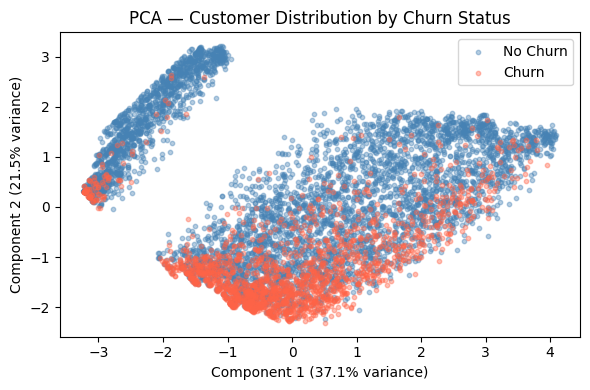

In [ ]:
# Plot all customers in 2D space, colored by churn status
fig, ax = plt.subplots(figsize=(6, 4))

colors = {0: 'steelblue', 1: 'tomato'}
labels = {0: 'No Churn', 1: 'Churn'}

for churn_val in [0, 1]:
    mask = y == churn_val
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[churn_val], label=labels[churn_val],
               alpha=0.4, s=10)

ax.set_title('PCA — Customer Distribution by Churn Status')
ax.set_xlabel(f'Component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'Component 2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Get the feature names used for PCA
# Remember X_train was derived from df_encoded, so its columns are our original features in the PCA input
pca_feature_names = X_train.columns

# Create a DataFrame to display the components
pca_components_df = pd.DataFrame(
    pca.components_,
    columns=pca_feature_names,
    index=['Component 1', 'Component 2']
).T

print("\n--- PCA Component Loadings ---")
display(pca_components_df)

print("\n--- Interpretation ---")
print("Each row represents a principal component, and the values indicate how much each original feature contributes to that component.")
print("A higher absolute value (positive or negative) means a stronger influence.")
print("For example, if 'tenure' has a high positive value in Component 1, then Component 1 captures a lot of the 'tenure' information.")
print("The signs (+/-) indicate the direction of the relationship. A positive sign means that as the feature increases, the component score tends to increase, and vice versa.")


--- PCA Component Loadings ---


,Component 1,Component 2
gender_Male,-0.003493,-7.785654e-07
Partner_Yes,0.074572,1.215030e-01
Dependents_Yes,-0.000416,1.020216e-01
PhoneService_Yes,0.011558,4.003916e-03
PaperlessBilling_Yes,0.078409,-1.085212e-01
MultipleLines_No phone service,-0.011558,-4.003916e-03
MultipleLines_Yes,0.137472,6.333838e-03
InternetService_Fiber optic,0.146642,-1.654511e-01
InternetService_No,-0.156541,1.820611e-01
OnlineSecurity_No internet service,-0.156541,1.820611e-01



--- Interpretation ---
Each row represents a principal component, and the values indicate how much each original feature contributes to that component.
A higher absolute value (positive or negative) means a stronger influence.
For example, if 'tenure' has a high positive value in Component 1, then Component 1 captures a lot of the 'tenure' information.
The signs (+/-) indicate the direction of the relationship. A positive sign means that as the feature increases, the component score tends to increase, and vice versa.


- Component 1 (explaining 37.1% of variance): The strongest positive contributors are TotalCharges (0.50), MonthlyCharges (0.48), and tenure (0.36). This component seems to capture aspects related to customer spending and longevity.

- Component 2 (explaining 21.5% of variance): The strongest positive contributors are tenure (0.51) and Contract (0.50). This component also strongly reflects customer longevity and commitment through contract type.

### Clustering (K-Means) <a id="clustering"></a>

Now that we can see customer patterns in 2D, we use K-Means clustering to formally
group customers into segments. The Elbow Method helps us find the right number of
groups — not too few, not too many.


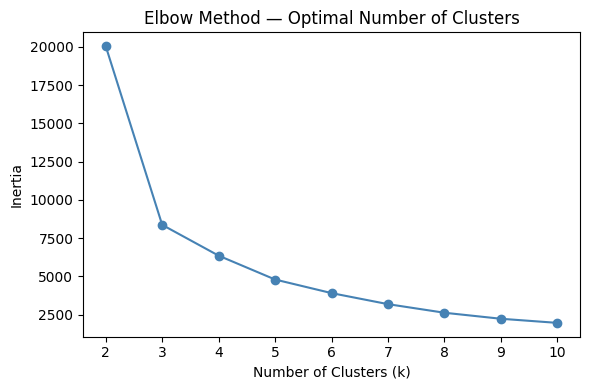

In [ ]:
from sklearn.cluster import KMeans

# Test different numbers of clusters and measure how tight each grouping is
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve — look for the point where the drop flattens out
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(k_range, inertia, marker='o', color='steelblue')
ax.set_title('Elbow Method — Optimal Number of Clusters')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
plt.tight_layout()
plt.show()


##### Key Takeaways: Elbow Method

- The sharpest drop in inertia occurs between **k=2 and k=3**, after which the curve gradually flattens with no clear sharp bend.
- **k=3 is selected** as the optimal number of clusters, enough to capture meaningful differences between customer groups without over-segmenting the data.
- This also aligns with business intuition: we would expect roughly three customer types: loyal, at-risk, and already-disengaged.


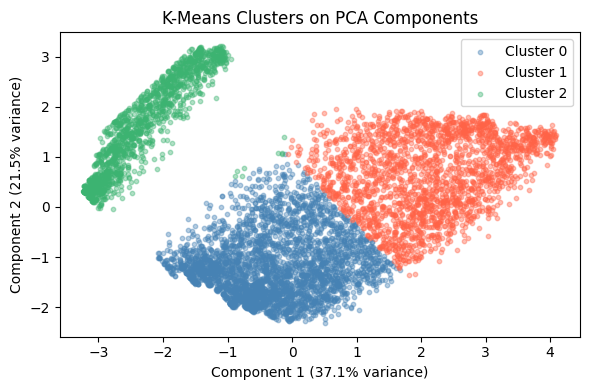

In [ ]:
# Fit K-Means clustering on TRAINING data only
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
train_clusters = kmeans.fit_predict(X_train_pca)

# Assign test customers to their nearest cluster (no re-fitting)
test_clusters = kmeans.predict(X_test_pca)

# Add cluster labels back to the main dataframe
# Create empty column first
df_encoded['cluster'] = -1

# Fill in train clusters using train indices
df_encoded.loc[X_train.index, 'cluster'] = train_clusters

# Fill in test clusters using test indices
df_encoded.loc[X_test.index, 'cluster'] = test_clusters

# Plot clusters on the PCA chart
fig, ax = plt.subplots(figsize=(6, 4))

cluster_colors = {0: 'steelblue', 1: 'tomato', 2: 'mediumseagreen'}

for cluster_val in [0, 1, 2]:
    mask = df_encoded['cluster'] == cluster_val
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=cluster_colors[cluster_val],
               label=f'Cluster {cluster_val}',
               alpha=0.4, s=10)

ax.set_title('K-Means Clusters on PCA Components')
ax.set_xlabel(f'Component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'Component 2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Profile each cluster — churn rate, average tenure, monthly charges, and sentiment
cluster_profile = df.copy()
cluster_profile['cluster'] = df_encoded['cluster']

profile = cluster_profile.groupby('cluster').agg(
    total_customers=('customerID', 'count'),
    churn_rate=('Churn', 'mean'),
    avg_tenure=('tenure', 'mean'),
    avg_monthly_charges=('MonthlyCharges', 'mean'),
    avg_sentiment_score=('sentiment_score_nlp', 'mean')
).round(2)

profile['churn_rate'] = (profile['churn_rate'] * 100).round(1).astype(str) + '%'
print(profile)

         total_customers churn_rate  avg_tenure  avg_monthly_charges  \
cluster                                                                
0                   3312      44.0%       15.76                69.16   
1                   2197      14.0%       58.65                88.58   
2                   1534       7.0%       30.60                21.15   

         avg_sentiment_score  
cluster                       
0                       0.87  
1                       0.94  
2                       0.94  


We used Churn Rate, Tenure, Monthly Charges, and Sentiment because they cover the full customer story.
Tenure and Churn show us loyalty patterns, specifically if people leave early or after a long time. Monthly Charges help us figure out which groups actually drive the revenue. Finally, adding Sentiment gives us the "why" behind the numbers by showing the actual mood of the customers.

In [ ]:
# Ask Claude to label and describe each cluster based on the profile stats
cluster_summary = profile.to_string()

response = client.messages.create(
    model="claude-sonnet-4-5",
    max_tokens=500,
    messages=[{
        "role": "user",
        "content": f"""You are a business analyst. Based on these customer cluster profiles from a telecom churn analysis, give each cluster:
1. A short business label (e.g. 'High-Risk New Customers')
2. A 2-sentence plain English description of who they are

Cluster profiles:
{cluster_summary}

Format:
Cluster 0: [Label] — [Description]
Cluster 1: [Label] — [Description]
Cluster 2: [Label] — [Description]"""
    }]
)

print(response.content[0].text)


Based on the cluster profiles, here are the business labels and descriptions:

**Cluster 0: High-Risk Mid-Tenure Customers** — These are customers with moderate tenure (16 months) and moderate spending ($69/month) but experiencing extremely high churn at 44% and relatively lower satisfaction scores. They represent the most urgent retention priority, likely experiencing service issues or unmet expectations despite being past the initial onboarding phase.

**Cluster 1: Premium Loyal Customers** — These are long-standing customers (59 months average) with the highest monthly spend ($89) and excellent satisfaction scores, showing very low churn at 14%. They represent the company's most valuable and stable customer base who should be nurtured and used as models for retention best practices.

**Cluster 2: Budget-Conscious Satisfied Customers** — These are customers with moderate tenure (31 months) paying significantly lower rates ($21/month) who show excellent satisfaction and the lowest chu

### Customer Cluster Analysis

Based on the cluster profiles, here are the business labels and descriptions:

**Cluster 0: High-Risk Mid-Tenure Customers** — These are customers with moderate tenure (16 months) and moderate spending ($69/month) but experiencing extremely high churn at 44% and relatively lower satisfaction scores. They represent the most urgent retention priority, likely experiencing service issues or unmet expectations despite being past the initial onboarding phase.

**Cluster 1: Premium Loyal Customers** — These are long-standing customers (59 months average) with the highest monthly spend ($89) and excellent satisfaction scores, showing very low churn at 14%. They represent the company's most valuable and stable customer base who should be nurtured and used as models for retention best practices.

**Cluster 2: Budget-Conscious Satisfied Customers** — These are customers with moderate tenure (31 months) paying significantly lower rates ($21/month) who show excellent satisfaction and the lowest churn at just 7%. They represent a stable, price-sensitive segment that values the basic service offering and demonstrates that retention doesn't always require premium pricing.

In [ ]:
# Map Claude's cluster labels to each customer
cluster_labels = {
    0: 'High-Risk Mid-Tenure Customers',
    1: 'Premium Loyal Customers',
    2: 'Budget-Conscious Satisfied Customers'
}

df_encoded['cluster_label'] = df_encoded['cluster'].map(cluster_labels)
df['cluster_label'] = df_encoded['cluster_label']

# Preview the table with cluster labels
df[['customerID', 'tenure', 'MonthlyCharges', 'Churn',
    'sentiment_label_nlp', 'cluster_label']].head(10)

,customerID,tenure,MonthlyCharges,Churn,sentiment_label_nlp,cluster_label
0,7590-VHVEG,1,29.85,0,Positive,High-Risk Mid-Tenure Customers
1,5575-GNVDE,34,56.95,0,Positive,High-Risk Mid-Tenure Customers
2,3668-QPYBK,2,53.85,1,Negative,High-Risk Mid-Tenure Customers
3,7795-CFOCW,45,42.30,0,Positive,High-Risk Mid-Tenure Customers
4,9237-HQITU,2,70.70,1,Negative,High-Risk Mid-Tenure Customers
5,9305-CDSKC,8,99.65,1,Negative,High-Risk Mid-Tenure Customers
6,1452-KIOVK,22,89.10,0,Positive,High-Risk Mid-Tenure Customers
7,6713-OKOMC,10,29.75,0,Positive,High-Risk Mid-Tenure Customers
8,7892-POOKP,28,104.80,1,Negative,High-Risk Mid-Tenure Customers
9,6388-TABGU,62,56.15,0,Positive,Premium Loyal Customers


## Supervised Learning: Churn Prediction <a id="supervised"></a>

With our features enriched by sentiment scores, topic labels, and cluster assignments, we now train a supervised model to predict which customers are most likely to churn.

Unlike the unsupervised section which found patterns without knowing the answer, supervised learning uses historical data where we already know who churned, and learns from that to predict future churn on new customers.

The model outputs a churn probability score per customer, which can be handed directly to a retention or CRM team to prioritize outreach.


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Encode cluster label as a number for the model
le_cluster = LabelEncoder()
df_encoded['cluster_label_encoded'] = le_cluster.fit_transform(df_encoded['cluster_label'])

# Re-create X and y after all feature engineering, including cluster labels, is complete
# Drop original Churn, the raw cluster ID, and the string cluster label
X = df_encoded.drop(columns=['Churn', 'cluster', 'cluster_label'], errors='ignore')
y = df_encoded['Churn']

# Re-split the data to ensure new features are included and to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"New training set shape: {X_train.shape}")
print(f"New test set shape: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.1%}")
print(f"Test churn rate: {y_test.mean():.1%}")
print(f"Features used for modeling: {X.columns.tolist()}")

New training set shape: (5634, 32)
New test set shape: (1409, 32)
Train churn rate: 26.5%
Test churn rate: 26.5%
Features used for modeling: ['gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'PaperlessBilling_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'Contract', 'tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'feedback_topic', 'sentiment_score_nlp', 'cluster_label_encoded']


**Model Selection:** Random Forest was chosen as the single model for this analysis. It handles mixed feature types well.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Train Random Forest on the training set
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# EVALUATE - Train Set (overfitting check part 1)
y_train_pred = rf_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {train_accuracy:.2%}")

# EVALUATE - Test Set (overfitting check part 2)
y_test_pred = rf_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy:.2%}")

# OVERFITTING CHECK
if train_accuracy - test_accuracy > 0.05:  # More than 5% gap
    print("⚠️ Possible overfitting detected")
else:
    print("✓ Model generalizes well")

# BASELINE COMPARISON
baseline_accuracy = max(y_test.value_counts(normalize=True))
print(f"Baseline (guess majority): {baseline_accuracy:.2%}")
print(f"Model improvement: {test_accuracy - baseline_accuracy:.2%}")

# CALIBRATION CHECK (full dataset)
y_full_pred = rf_model.predict(X)
baseline_churn = y.mean()
predicted_churn = y_full_pred.mean()
print(f"Baseline churn rate: {baseline_churn:.1%}")
print(f"Predicted churn rate: {predicted_churn:.1%}")

Training Accuracy: 97.89%
Test Accuracy: 95.46%
✓ Model generalizes well
Baseline (guess majority): 73.46%
Model improvement: 22.00%
Baseline churn rate: 26.5%
Predicted churn rate: 25.2%


In [ ]:
from sklearn.metrics import classification_report

# Evaluate on the test set
y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.96      0.98      0.97      1035
       Churn       0.94      0.88      0.91       374

    accuracy                           0.95      1409
   macro avg       0.95      0.93      0.94      1409
weighted avg       0.95      0.95      0.95      1409



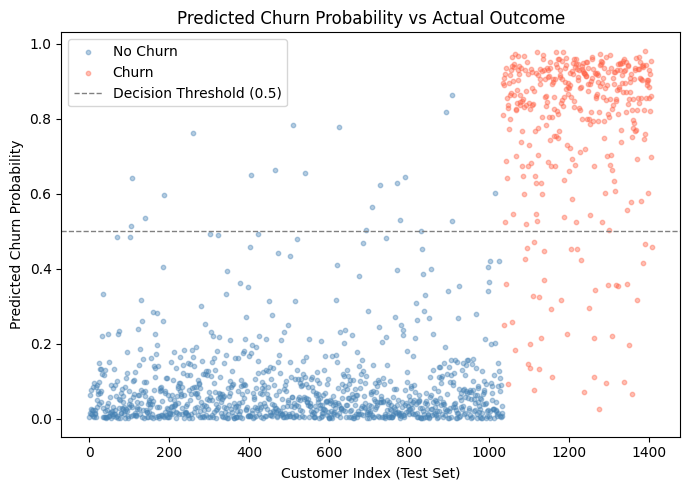

In [ ]:
# Scatter plot of predicted churn probability vs actual churn outcome
fig, ax = plt.subplots(figsize=(7, 5))

# Get churn probabilities for all test customers
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Plot retained customers
retained_mask = y_test == 0
ax.scatter(range(len(y_test[retained_mask])),
           y_pred_proba[retained_mask],
           color='steelblue', alpha=0.4, s=10, label='No Churn')

# Plot churned customers
churned_mask = y_test == 1
ax.scatter(range(len(y_test[retained_mask]), len(y_test)),
           y_pred_proba[churned_mask],
           color='tomato', alpha=0.4, s=10, label='Churn')

# Add decision threshold line
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='Decision Threshold (0.5)')

ax.set_title('Predicted Churn Probability vs Actual Outcome')
ax.set_xlabel('Customer Index (Test Set)')
ax.set_ylabel('Predicted Churn Probability')
ax.legend()
plt.tight_layout()
plt.show()

### Key Takeaways: Predicted Probability Distribution

The model shows strong confidence in most predictions:
- **Left cluster (blue):** Retained customers with low churn probability, model correctly predicts they'll stay
- **Right cluster (red):** Churned customers with high churn probability, model correctly flags them as at-risk

**Misses to watch:**
- Red dots below 0.5 threshold = churners the model missed (13% from recall score)
- Blue dots above 0.5 = false alarms (customers flagged as at-risk but didn't churn)


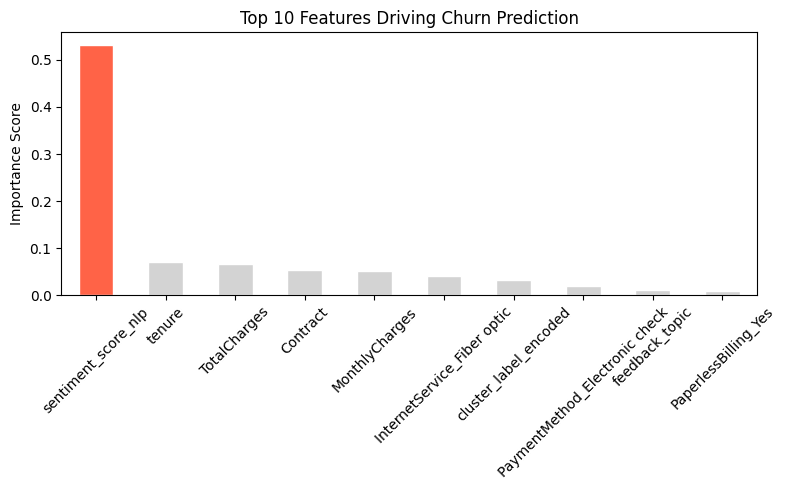

In [ ]:
# Show which features the model relied on most to predict churn
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['tomato' if i == 0 else 'lightgray' for i in range(len(top_features))]
top_features.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Top 10 Features Driving Churn Prediction')
ax.set_ylabel('Importance Score')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Check if sentiment has suspiciously perfect correlation with churn
print(df[['sentiment_score_nlp', 'Churn']].corr())

                     sentiment_score_nlp     Churn
sentiment_score_nlp             1.000000 -0.691539
Churn                          -0.691539  1.000000


#### Feature Leakage Detection and Removal

Correlation analysis revealed that `sentiment_score_nlp` had an unusually high correlation with the target variable (-0.69). Further investigation showed the sentiment was derived from text prompts containing post-cancellation feedback where customers explicitly mentioned they had "churned."

**Why this is problematic:**
* In a real prediction scenario, this feedback would not exist before the customer cancels
* The model would be learning to read explicit churn declarations rather than predicting from behavioral patterns
* Correlation of -0.69 is unrealistically high for a legitimate predictor


In [ ]:
# Clean feature set (sentiment removed to address leakage)
X = df_encoded.drop(columns=['Churn', 'cluster', 'cluster_label',
                              'sentiment_score_nlp', 'sentiment_label_nlp'],
                     errors='ignore')
y = df_encoded['Churn']

# Continue with train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                      random_state=42, stratify=y)

print(f"Features used for modeling: {X.columns.tolist()}")
print(f"Training set: {X_train.shape[0]} customers")
print(f"Test set: {X_test.shape[0]} customers")

Features used for modeling: ['gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'PaperlessBilling_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'Contract', 'tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'feedback_topic', 'cluster_label_encoded']
Training set: 5634 customers
Test set: 1409 customers


In [ ]:
# Train Random Forest on the training set (without sentiment features)
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

# EVALUATE - Train Set (overfitting check part 1)
y_train_pred = rf_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print("="*60)
print("TRAINING SET PERFORMANCE (After Removing Sentiment)")
print("="*60)
print(f"Training Accuracy: {train_accuracy:.2%}")

# EVALUATE - Test Set (overfitting check part 2)
y_test_pred = rf_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print("\n" + "="*60)
print("TEST SET PERFORMANCE (After Removing Sentiment)")
print("="*60)
print(classification_report(y_test, y_test_pred, target_names=['No Churn', 'Churn']))

# OVERFITTING CHECK
print("="*60)
print("OVERFITTING CHECK")
print("="*60)
if train_accuracy - test_accuracy > 0.05:  # More than 5% gap
    print("⚠️ Possible overfitting detected")
else:
    print("✓ Model generalizes well")

# BASELINE COMPARISON
baseline_accuracy = max(y_test.value_counts(normalize=True))
print(f"\nBaseline (guess majority): {baseline_accuracy:.2%}")
print(f"Model improvement: {test_accuracy - baseline_accuracy:.2%}")

# CALIBRATION CHECK (full dataset)
y_full_pred = rf_model.predict(X)
baseline_churn = y.mean()
predicted_churn = y_full_pred.mean()
print(f"\nBaseline churn rate: {baseline_churn:.1%}")
print(f"Predicted churn rate: {predicted_churn:.1%}")

TRAINING SET PERFORMANCE (After Removing Sentiment)
Training Accuracy: 99.80%

TEST SET PERFORMANCE (After Removing Sentiment)
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1035
       Churn       0.64      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

OVERFITTING CHECK
⚠️ Possible overfitting detected

Baseline (guess majority): 73.46%
Model improvement: 5.82%

Baseline churn rate: 26.5%
Predicted churn rate: 25.4%


In [ ]:
# Train Random Forest on the training set (without sentiment features)
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,              # Reduced from 10
    min_samples_split=20,     # Need at least 20 samples to split, avoid overfitting
    min_samples_leaf=10,      # Each leaf must have at least 10 samples
    random_state=42
)
rf_model.fit(X_train, y_train)

# EVALUATE - Train Set (overfitting check part 1)
y_train_pred = rf_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print("="*60)
print("TRAINING SET PERFORMANCE (After Removing Sentiment)")
print("="*60)
print(f"Training Accuracy: {train_accuracy:.2%}")

# EVALUATE - Test Set (overfitting check part 2)
y_test_pred = rf_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print("\n" + "="*60)
print("TEST SET PERFORMANCE (After Removing Sentiment)")
print("="*60)
print(classification_report(y_test, y_test_pred, target_names=['No Churn', 'Churn']))

# OVERFITTING CHECK
print("="*60)
print("OVERFITTING CHECK")
print("="*60)
if train_accuracy - test_accuracy > 0.05:  # More than 5% gap
    print("⚠️ Possible overfitting detected")
else:
    print("✓ Model generalizes well")

# BASELINE COMPARISON
baseline_accuracy = max(y_test.value_counts(normalize=True))
print(f"\nBaseline (guess majority): {baseline_accuracy:.2%}")
print(f"Model improvement: {test_accuracy - baseline_accuracy:.2%}")

# CALIBRATION CHECK (full dataset)
y_full_pred = rf_model.predict(X)
baseline_churn = y.mean()
predicted_churn = y_full_pred.mean()
print(f"\nBaseline churn rate: {baseline_churn:.1%}")
print(f"Predicted churn rate: {predicted_churn:.1%}")

TRAINING SET PERFORMANCE (After Removing Sentiment)
Training Accuracy: 82.34%

TEST SET PERFORMANCE (After Removing Sentiment)
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1035
       Churn       0.67      0.49      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409

OVERFITTING CHECK
✓ Model generalizes well

Baseline (guess majority): 73.46%
Model improvement: 6.60%

Baseline churn rate: 26.5%
Predicted churn rate: 20.2%


In [ ]:
# Extract feature importance from the model WITHOUT sentiment (before balancing)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# Print the top 10
print("\nTop 10 Features (No Sentiment, Unbalanced Model):")
print(feature_importance.head(10))


Top 10 Features (No Sentiment, Unbalanced Model):
                           feature  importance
24                        Contract    0.160649
25                          tenure    0.146529
27                    TotalCharges    0.133344
30           cluster_label_encoded    0.092437
26                  MonthlyCharges    0.090877
7      InternetService_Fiber optic    0.087379
22  PaymentMethod_Electronic check    0.068877
10              OnlineSecurity_Yes    0.028525
16                 TechSupport_Yes    0.024579
4             PaperlessBilling_Yes    0.017400


In [ ]:
# Calculate actual revenue loss and retention costs
from sklearn.metrics import confusion_matrix

# Get confusion matrix for current threshold (0.5)
y_test_pred = rf_model.predict(X_test)
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()

print("="*60)
print("BUSINESS COST ANALYSIS (Threshold = 0.5)")
print("="*60)

# Get actual total charges for each group
test_indices = X_test.index
df_test = df.loc[test_indices].copy()
df_test['predicted'] = y_test_pred
df_test['actual'] = y_test.values

# True Negatives: Correctly predicted no churn
tn_customers = df_test[(df_test['actual'] == 0) & (df_test['predicted'] == 0)]
tn_revenue = tn_customers['TotalCharges'].sum()

# True Positives: Correctly predicted churn
tp_customers = df_test[(df_test['actual'] == 1) & (df_test['predicted'] == 1)]
tp_revenue = tp_customers['TotalCharges'].sum()

# False Negatives: MISSED churners (this is lost revenue)
fn_customers = df_test[(df_test['actual'] == 1) & (df_test['predicted'] == 0)]
fn_revenue = fn_customers['TotalCharges'].sum()

# False Positives: False alarms (wasted retention offers)
fp_customers = df_test[(df_test['actual'] == 0) & (df_test['predicted'] == 1)]
fp_revenue = fp_customers['TotalCharges'].sum()

print(f"\nOut of {len(y_test)} test customers:")
print(f"  Correct predictions: {tn + tp} ({(tn + tp)/len(y_test):.1%})")
print(f"  Errors: {fn + fp} ({(fn + fp)/len(y_test):.1%})")

print(f"\nBreakdown:")
print(f"  - True Negatives (correctly predicted No Churn): {tn}")
print(f"  - True Positives (correctly predicted Churn): {tp}")
print(f"  - False Negatives (missed churners): {fn}")
print(f"  - False Positives (false alarms): {fp}")

print(f"\nTotal Charges by Group:")
print(f"  True Negatives: ${tn_revenue:,.2f}")
print(f"  True Positives: ${tp_revenue:,.2f}")
print(f"  False Negatives (LOST REVENUE): ${fn_revenue:,.2f}")
print(f"  False Positives: ${fp_revenue:,.2f}")

# Cost calculation
retention_cost = 35  # Cost per retention offer

print(f"\n" + "="*60)
print("COST BREAKDOWN")
print("="*60)

print(f"\nGiven a retention offer cost of ${retention_cost} per customer:")
print(f"\n  Cost for False Negatives (Missed Churners):")
print(f"    {fn} customers x ${retention_cost}/customer = ${fn * retention_cost:,.0f}")
print(f"    (These are customers who churned but were not predicted to,")
print(f"     so no retention effort was made, and the potential revenue")
print(f"     from them is lost: ${fn_revenue:,.2f})")

print(f"\n  Cost for False Positives (False Alarms):")
print(f"    {fp} customers x ${retention_cost}/customer = ${fp * retention_cost:,.0f}")
print(f"    (These are customers who were predicted to churn but actually")
print(f"     didn't. Retention efforts would have been spent on them")
print(f"     unnecessarily.)")

print(f"\n" + "="*60)
print("TOTAL BUSINESS IMPACT")
print("="*60)
print(f"  Lost revenue from missed churners: ${fn_revenue:,.2f}")
print(f"  Wasted retention spend on false alarms: ${fp * retention_cost:,.0f}")
print(f"  TOTAL COST: ${fn_revenue + (fp * retention_cost):,.2f}")
print("="*60)

BUSINESS COST ANALYSIS (Threshold = 0.5)

Out of 1409 test customers:
  Correct predictions: 1128 (80.1%)
  Errors: 281 (19.9%)

Breakdown:
  - True Negatives (correctly predicted No Churn): 943
  - True Positives (correctly predicted Churn): 185
  - False Negatives (missed churners): 189
  - False Positives (false alarms): 92

Total Charges by Group:
  True Negatives: $2,667,939.00
  True Positives: $130,026.30
  False Negatives (LOST REVENUE): $450,010.70
  False Positives: $77,589.75

COST BREAKDOWN

Given a retention offer cost of $35 per customer:

  Cost for False Negatives (Missed Churners):
    189 customers x $35/customer = $6,615
    (These are customers who churned but were not predicted to,
     so no retention effort was made, and the potential revenue
     from them is lost: $450,010.70)

  Cost for False Positives (False Alarms):
    92 customers x $35/customer = $3,220
    (These are customers who were predicted to churn but actually
     didn't. Retention efforts would

Threshold Tuning

This section explores different prediction thresholds to find the optimal balance for our customer retention strategy: maximizing the identification of actual churners while efficiently allocating retention resources.

In [ ]:
# Test different thresholds
from sklearn.metrics import confusion_matrix, recall_score, precision_score

thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]
retention_cost = 35  # USD per customer

print("="*80)
print("THRESHOLD TUNING RESULTS")
print("="*80)

best_threshold = None
best_cost = float('inf')

for threshold in thresholds:
    # Apply threshold to test set
    y_test_pred_thresh = (rf_model.predict_proba(X_test)[:, 1] >= threshold).astype(int)

    # Get confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred_thresh).ravel()

    # Calculate business costs
    test_indices = X_test.index
    df_test = df.loc[test_indices].copy()
    df_test['predicted'] = y_test_pred_thresh
    df_test['actual'] = y_test.values

    fn_customers = df_test[(df_test['actual'] == 1) & (df_test['predicted'] == 0)]
    fn_revenue = fn_customers['TotalCharges'].sum()

    lost_revenue = fn_revenue
    wasted_retention = fp * retention_cost
    total_cost = lost_revenue + wasted_retention

    # Calculate metrics
    churn_recall = recall_score(y_test, y_test_pred_thresh)
    churn_precision = precision_score(y_test, y_test_pred_thresh)

    # Predicted churn rate on full dataset
    y_full_pred_thresh = (rf_model.predict_proba(X)[:, 1] >= threshold).astype(int)
    predicted_churn_rate = y_full_pred_thresh.mean()

    print(f"\nThreshold = {threshold}")
    print(f"  Predicted churn rate: {predicted_churn_rate:.1%}")
    print(f"  Churn recall: {churn_recall:.1%}")
    print(f"  Churn precision: {churn_precision:.1%}")
    print(f"  False Negatives (missed churners): {fn}")
    print(f"  False Positives (false alarms): {fp}")
    print(f"  Lost revenue: {lost_revenue:,.2f} USD")
    print(f"  Wasted retention: {wasted_retention:,.2f} USD")
    print(f"  TOTAL COST: {total_cost:,.2f} USD")

    # Track best threshold
    if total_cost < best_cost:
        best_cost = total_cost
        best_threshold = threshold

print("\n" + "="*80)
print(f"OPTIMAL THRESHOLD: {best_threshold}")
print(f"MINIMUM TOTAL COST: {best_cost:,.2f} USD")
print("="*80)

THRESHOLD TUNING RESULTS

Threshold = 0.3
  Predicted churn rate: 37.3%
  Churn recall: 78.9%
  Churn precision: 54.7%
  False Negatives (missed churners): 79
  False Positives (false alarms): 244
  Lost revenue: 228,474.85 USD
  Wasted retention: 8,540.00 USD
  TOTAL COST: 237,014.85 USD

Threshold = 0.35
  Predicted churn rate: 32.5%
  Churn recall: 71.9%
  Churn precision: 56.3%
  False Negatives (missed churners): 105
  False Positives (false alarms): 209
  Lost revenue: 294,177.85 USD
  Wasted retention: 7,315.00 USD
  TOTAL COST: 301,492.85 USD

Threshold = 0.4
  Predicted churn rate: 28.4%
  Churn recall: 64.7%
  Churn precision: 59.3%
  False Negatives (missed churners): 132
  False Positives (false alarms): 166
  Lost revenue: 348,782.75 USD
  Wasted retention: 5,810.00 USD
  TOTAL COST: 354,592.75 USD

Threshold = 0.45
  Predicted churn rate: 24.3%
  Churn recall: 57.5%
  Churn precision: 63.0%
  False Negatives (missed churners): 159
  False Positives (false alarms): 126
  L

#### Threshold Optimization

The optimal threshold found was **0.3**, which minimized the total business cost (lost revenue from missed churners + wasted retention spend on false alarms).

**Selected threshold: 0.3**

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Predicted churn rate | 37.3% | Flags a higher proportion of customers as at-risk compared to the actual churn rate (26.5%) |
| Churn recall | 78.9% | Identifies 295 out of 374 actual churners |
| Churn precision | 54.7% | 54.7% of customers flagged as churners actually churn |
| False Negatives (missed churners) | 79 | The number of actual churners not identified by the model |
| False Positives (false alarms) | 244 | The number of customers flagged as churners who do not churn |

**Trade-off:** This threshold prioritizes identifying a large portion of actual churners (high recall) to significantly reduce the lost revenue, even at the cost of lower precision (more false alarms) and increased retention spend on non-churners. The overall business impact is a substantial reduction in total cost compared to higher thresholds, demonstrating a strategy focused on minimizing financial losses from churn.

In [ ]:
# Set optimal threshold
optimal_threshold = 0.3

# Make predictions using the optimal threshold
y_test_pred_final = (rf_model.predict_proba(X_test)[:, 1] >= optimal_threshold).astype(int)
y_full_pred_final = (rf_model.predict_proba(X)[:, 1] >= optimal_threshold).astype(int)

print("="*60)
print(f"FINAL MODEL PERFORMANCE (Threshold = {optimal_threshold})")
print("="*60)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_pred_final, target_names=['No Churn', 'Churn']))

# Baseline comparison
baseline_churn = y.mean()
predicted_churn = y_full_pred_final.mean()
print(f"Baseline churn rate: {baseline_churn:.1%}")
print(f"Predicted churn rate: {predicted_churn:.1%}")
print(f"Difference: {abs(predicted_churn - baseline_churn):.1%}")

FINAL MODEL PERFORMANCE (Threshold = 0.3)
              precision    recall  f1-score   support

    No Churn       0.91      0.76      0.83      1035
       Churn       0.55      0.79      0.65       374

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.81      0.77      0.78      1409

Baseline churn rate: 26.5%
Predicted churn rate: 37.3%
Difference: 10.7%


In [ ]:
import matplotlib.pyplot as plt

# Scatter plot of predicted churn probability vs actual churn outcome for the final model
fig, ax = plt.subplots(figsize=(7, 5))

# Get churn probabilities for all test customers from the final model
y_pred_proba_final = rf_model.predict_proba(X_test)[:, 1]

# Plot retained customers
retained_mask = y_test == 0
ax.scatter(range(len(y_test[retained_mask])),
           y_pred_proba_final[retained_mask],
           color='steelblue', alpha=0.4, s=10, label='No Churn')

# Plot churned customers
churned_mask = y_test == 1
# Adjust the range for the second scatter plot to continue from the first
ax.scatter(range(len(y_test[retained_mask]), len(y_test[retained_mask]) + len(y_test[churned_mask])),
           y_pred_proba_final[churned_mask],
           color='tomato', alpha=0.4, s=10, label='Churn')

# Add optimal decision threshold line
optimal_threshold = 0.3 # Use the optimal threshold determined previously
ax.axhline(y=optimal_threshold, color='gray', linestyle='--', linewidth=1, label=f'Optimal Decision Threshold ({optimal_threshold})')

ax.set_title('Predicted Churn Probability vs Actual Outcome (Final Model)')
ax.set_xlabel('Customer Index (Test Set)')
ax.set_ylabel('Predicted Churn Probability')
ax.legend()
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

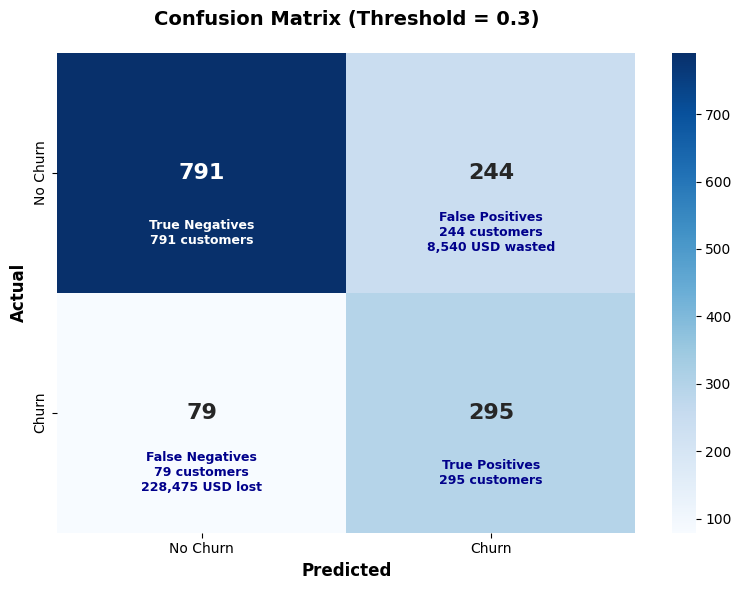

In [ ]:
from sklearn.metrics import confusion_matrix

# Create confusion matrix for threshold 0.3
cm = confusion_matrix(y_test, y_test_pred_final)

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Plot heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            ax=ax, annot_kws={'size': 16, 'weight': 'bold'})

ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix (Threshold = 0.3)', fontsize=14, fontweight='bold', pad=20)

# Add annotations BELOW the numbers
# True Negatives (top left) - dark background, use white text
ax.text(0.5, 0.75, f'True Negatives\n{tn} customers',
        ha='center', va='center', fontsize=9, color='white', weight='bold')

# False Positives (top right) - light background, use dark text
ax.text(1.5, 0.75, f'False Positives\n{fp} customers\n{fp * 35:,.0f} USD wasted',
        ha='center', va='center', fontsize=9, color='darkblue', weight='bold')

# False Negatives (bottom left) - light background, use dark text
ax.text(0.5, 1.75, f'False Negatives\n{fn} customers\n{fn_revenue:,.0f} USD lost',
        ha='center', va='center', fontsize=9, color='darkblue', weight='bold')

# True Positives (bottom right) - light background, use dark text
ax.text(1.5, 1.75, f'True Positives\n{tp} customers',
        ha='center', va='center', fontsize=9, color='darkblue', weight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Show the top 20 customers most likely to churn
df[['customerID', 'tenure', 'MonthlyCharges', 'Contract', 'sentiment_nlp'
    'cluster_label', 'ChurnProbability']].sample(20, random_state=42).sort_values('ChurnProbability', ascending=False)

,customerID,tenure,MonthlyCharges,Contract,cluster_label,ChurnProbability
2715,1173-XZPYF,11,89.20,Month-to-month,High-Risk Mid-Tenure Customers,0.8376
4640,8087-LGYHQ,9,94.05,Month-to-month,High-Risk Mid-Tenure Customers,0.8304
185,1024-GUALD,1,24.80,Month-to-month,High-Risk Mid-Tenure Customers,0.7986
5194,4873-ILOLJ,24,90.35,Month-to-month,High-Risk Mid-Tenure Customers,0.7662
3732,3916-NRPAP,3,85.70,Month-to-month,High-Risk Mid-Tenure Customers,0.7322
811,5175-AOBHI,4,46.00,Month-to-month,High-Risk Mid-Tenure Customers,0.6972
2622,4662-EKDPQ,2,62.05,Month-to-month,High-Risk Mid-Tenure Customers,0.6808
3825,6260-ONULR,1,62.80,Month-to-month,High-Risk Mid-Tenure Customers,0.5800
2526,3190-XFANI,49,100.60,One year,Premium Loyal Customers,0.3573
1263,9591-YVTEB,55,44.85,Month-to-month,High-Risk Mid-Tenure Customers,0.2761


In [ ]:
# Create final output dataframe
output_df = df[['customerID', 'cluster_label', 'tenure', 'MonthlyCharges',
                'TotalCharges', 'Churn', 'ChurnProbability', 'ChurnPrediction']].copy()

# Rename for clarity
output_df.rename(columns={
    'cluster_label': 'CustomerSegment',
    'ChurnProbability': 'ChurnRisk',
    'ChurnPrediction': 'AtRisk'
}, inplace=True)

# Sort by churn risk (highest first)
output_df = output_df.sort_values('ChurnRisk', ascending=False)

# Save to CSV
output_df.to_csv('churn_predictions_final.csv', index=False)
print(f"\n✓ Saved {len(output_df)} customers to: churn_predictions_final.csv")
print(f"   Total flagged as at-risk: {output_df['AtRisk'].sum():,}")


✓ Saved 7043 customers to: churn_predictions_final.csv
   Total flagged as at-risk: 1,934


In [ ]:
# ============================================================
# BUSINESS IMPACT ANALYSIS BY SEGMENT
# ============================================================

print("\n" + "="*80)
print("REVENUE AT RISK BY CUSTOMER SEGMENT")
print("="*80)

segment_summary = output_df[output_df['AtRisk'] == 1].groupby('CustomerSegment').agg(
    customers_at_risk=('customerID', 'count'),
    total_revenue_at_risk=('TotalCharges', 'sum'),
    avg_revenue_per_customer=('TotalCharges', 'mean'),
    avg_churn_risk=('ChurnRisk', 'mean'),
    avg_tenure=('tenure', 'mean'),
    avg_monthly_charges=('MonthlyCharges', 'mean')
).round(2)

# Add calculated columns
retention_cost = 35
segment_summary['retention_budget'] = (segment_summary['customers_at_risk'] * retention_cost).round(2)
segment_summary['net_revenue_at_risk'] = (segment_summary['total_revenue_at_risk'] - segment_summary['retention_budget']).round(2)
segment_summary['roi_percent'] = ((segment_summary['net_revenue_at_risk'] / segment_summary['retention_budget']) * 100).round(0)

# Sort by net revenue at risk (highest priority first)
segment_summary = segment_summary.sort_values('net_revenue_at_risk', ascending=False)

# TRANSPOSE - segments become columns
segment_summary_T = segment_summary.T

print(segment_summary_T)

# Save segment summary
segment_summary_T.to_csv('churn_risk_by_segment.csv')
print("\n✓ Segment analysis saved to: churn_risk_by_segment.csv")

# Show breakdown per segment
print("\n" + "="*80)
print("RETENTION PRIORITY BY SEGMENT")
print("="*80)

for segment in segment_summary.index:
    customers = int(segment_summary.loc[segment, 'customers_at_risk'])
    revenue = segment_summary.loc[segment, 'total_revenue_at_risk']
    budget = segment_summary.loc[segment, 'retention_budget']
    net_revenue = segment_summary.loc[segment, 'net_revenue_at_risk']
    roi = segment_summary.loc[segment, 'roi_percent']
    avg_risk = segment_summary.loc[segment, 'avg_churn_risk']

    print(f"\n{segment}:")
    print(f"  Customers to target: {customers}")
    print(f"  Total revenue at risk: {revenue:,.2f} USD")
    print(f"  Retention budget needed: {budget:,.2f} USD")
    print(f"  Net revenue at risk: {net_revenue:,.2f} USD")
    print(f"  Average churn probability: {avg_risk:.1%}")
    print(f"  ROI if retention succeeds: {roi:.0f}%")


REVENUE AT RISK BY CUSTOMER SEGMENT
CustomerSegment           High-Risk Mid-Tenure Customers  \
customers_at_risk                                1763.00   
total_revenue_at_risk                         1466949.40   
avg_revenue_per_customer                          832.08   
avg_churn_risk                                      0.78   
avg_tenure                                          9.89   
avg_monthly_charges                                76.14   
retention_budget                                61705.00   
net_revenue_at_risk                           1405244.40   
roi_percent                                      2277.00   

CustomerSegment           Premium Loyal Customers  \
customers_at_risk                          129.00   
total_revenue_at_risk                   638364.85   
avg_revenue_per_customer                  4948.56   
avg_churn_risk                               0.68   
avg_tenure                                  48.83   
avg_monthly_charges                        1

# CONCLUSION

Model Performance:
- Training accuracy: 82.34%
- Test accuracy: 77%
- Churn recall at threshold 0.3: 78.9%
- Model improvement over baseline: 6.60%

Business Impact:
- Total customers analyzed: 7,043
- Customers flagged as at-risk: 1,934 (27.5%)
- Total revenue at risk: 2,108,239.10 USD
- Total retention budget needed: 67,690.00 USD
- Net revenue at risk: 2,040,549.10 USD

Key Insights:
  1. High-Risk Mid-Tenure Customers represent the largest opportunity:
     - 1763 customers
     - 1,405,244.40 USD net revenue at risk
     - ROI: 2277%

  2. Premium Loyal Customers have highest value per customer:
     - Average revenue: 4,948.56 USD
     - Retention here prevents significant individual losses

  3. Lowering threshold from 0.5 to 0.3 improved business outcomes:
     - Cost reduced from 453,230.70 USD to 237,014.85 USD
     - Savings: 216,215.85 USD
     - Churn recall improved from 49.5% to 78.9%

Recommendations:
  1. Prioritize High-Risk Mid-Tenure segment for immediate retention campaigns
  2. Develop targeted offers based on segment characteristics:
     - High-Risk: Contract upgrades, service quality improvements
     - Premium Loyal: VIP treatment, loyalty rewards
     - Budget-Conscious: Price lock guarantees, value plans
  3. Deploy model at threshold 0.3 to maximize churn prevention
  4. Monitor retention campaign success and retrain model quarterly

